[활동목표]]

인구 데이터를 분석하여 시각화에 담긴 의미를 찾아낼 수 있다.

[활동개요]

우리나라 연령대별, 성별 데이터를 이용하여 전국의 연령별 남녀의 인구수를 비교하는 실습으로 인구 구조와 남녀 인구수 차이 등을 비교 분석해 보자.

###나이별 인구 현황 데이터를 분석하여 문제를 해결할 수 있도록 시각화해 보자.

한글처리 위해 <아래코드 실행 -> 런타임 다시시작 -> 코드실행>

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt   # 시각화를 위한 라이브러리

# 레티나 디스플레이를 지원하도록 해서 한글이 흐릿하게 보이는 현상 개선
%config InlineBackend.figure_format = 'retina'

#한글 나눔 폰트 사용설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

 # 해당 폰트를 기본 폰트가 되도록 설정
import matplotlib.font_manager as fm
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font = fm.FontProperties(fname=fontpath, size=9)
plt.rc('font', family='NanumBarunGothic')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 16 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

1.인구 데이터 다운로드 및 불러오기  (https://jumin.mois.go.k)

① 나이별 인구 현황 데이터 다운로드

행정안전부의 주민등록 인구 통계 사이트에서 [연령별 인구 현황]을 클릭한다. 통계표에서 구분의 계, 남·여 구분에 모두 체크하고 연령 구분 단위는 [1세], 만 연령 구분은 [0~100세 이상]으로 설정하여 검색한다. [csv파일 다운로드]를 클릭하여 다운로드하고 파일 이름을 “korea_pop.csv”로 변경해 보자.

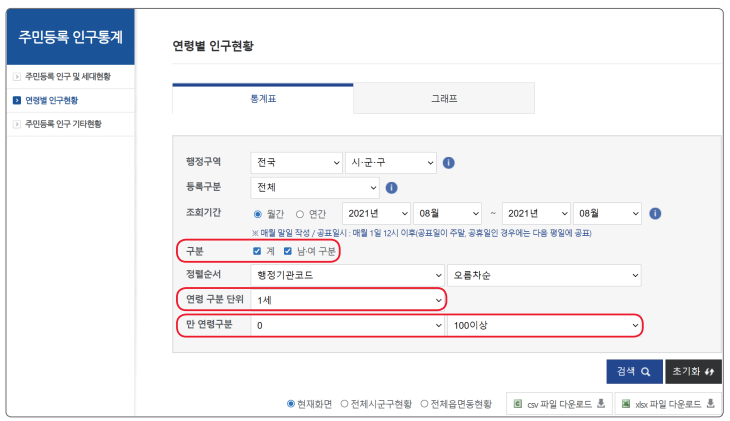

② 데이터 코랩으로 불러오기

pandas 라이브러리를 이용하여 “korea_pop.csv” 파일을 업로드한 후, 상위 5개의 데이터만 출력해 보자.

In [8]:
#라이브러리 불러오고, 데이터 파일 업로드하기
import pandas as pd
import numpy as np
import matplotlib.pyplot as pit

from google.colab import files
myfile=files.upload()

Saving korea_pop.csv to korea_pop.csv


In [9]:
#업로드한 데이터를 pandas의 데이터 프레임에 저장하기
#read_csv 옵션 : encoding = 'cp949': 한글 인식 / thousands = ',': 천 단위 구분 기호 삭제
df_pop = pd.read_csv("korea_pop.csv", encoding='cp949', thousands = ',')
df_pop.head()

,행정구역,2021년08월_계_총인구수,2021년08월_계_연령구간인구수,2021년08월_계_0세,2021년08월_계_1세,2021년08월_계_2세,2021년08월_계_3세,2021년08월_계_4세,2021년08월_계_5세,2021년08월_계_6세,...,2021년08월_여_91세,2021년08월_여_92세,2021년08월_여_93세,2021년08월_여_94세,2021년08월_여_95세,2021년08월_여_96세,2021년08월_여_97세,2021년08월_여_98세,2021년08월_여_99세,2021년08월_여_100세 이상
0,전국 (0000000000),51669716,51669716,257499,283694,312494,341766,377415,427561,445094,...,40386,32569,25335,18536,12489,9167,6018,6226,3755,8705
1,서울특별시 (1100000000),9550227,9550227,44089,46362,50261,53250,58004,65651,68040,...,5965,5026,3978,2934,2006,1414,1044,995,634,1893
2,부산광역시 (2600000000),3359527,3359527,14236,16009,17708,20244,22508,25598,26430,...,2285,1965,1630,1115,696,549,337,313,200,605
3,대구광역시 (2700000000),2393626,2393626,10437,12187,13465,15278,17145,19530,20295,...,1527,1207,1015,734,431,328,204,182,133,304
4,인천광역시 (2800000000),2938429,2938429,14537,16369,18434,19449,21741,24558,25869,...,1990,1606,1186,968,643,532,316,290,194,422


2.전국의 연령별 남녀 인구수 비교

① 피라미드형 그래프로 표현하기

0세부터 100세 이상의 연령별 남녀의 인구수를 가로 막대그래프를 이용하여 피라미드 형태로 표현해 보자.

In [ ]:
#남자 0세(106번째 속성)부터 100세 이상(206번째 속성)까지를 추출하여 numpy로 변환한다.
all_man=df_pop(np.arange[0,106:207]).to_numpy()

#여자 0세(209번째 속성, 뒤에서 101번째 속성)부터 100세 이상 (309번째 속성)까지를 추출하여 numpy로 변환한다.
all_woman=df_pop(np.arange[0,-101:]).to_numpy()

x = np.arange(0, 101) #그래프의 x축 설정(0~100)


#남자 데이터는 가로 막대가 양의 방향으로 출력되도록 그래프를 그린다.


#여자 데이터는 가로 막대가 음의 방향으로 출력되도록 그래프를 그린다.




② 연령별 남녀 인구수의 차이 그래프 그리기

연령별 남녀 인구수의 차이를 계산하여 막대그래프로 나타내 보자.

In [ ]:
#그래프의 크기를 설정한다.
plt.figure(figsize = (15, 5))

#남자와 여자 인구수의 차이를 y에 저장한다.


#남녀 인구수의 차를 빨간색의 막대그래프로 표현한다.


#0세부터 100세까지를 5살 단위로 표현한다.


3.제주도의 연령별 남녀 인구수 비교

① 제주도 인구 피라미드형 그래프를 그리기
제주도의 남녀 인구의 차이를 알아보기 위해 ‘제주특별자치도 (5000000000)’ 행정 구역의 데이터를 추출하여 연령별 남녀 인구수를 피라미드 그래프로 나타내 보자.

In [13]:
#제주도의 남녀 인구수 데이터만 추출하여 그래프 그리기

df_jeju = df_pop[df_pop['행정구역'].str.contains('제주')]
jeju_man = df_pop(np.arange[0,106:207]).to_numpy()
jeju_woman = df_pop
x = np.arange(0, 101)
plt.figure(figsize = (15, 10))
plt.barh(x, jeju_man, label = "제주 남자")
plt.barh(x, -jeju_woman, label = '제주 여자')
plt.yticks(np.arange(0, 101, 5))
plt.legend( )
plt.show( )
print('제주남여 차이는 :', np.sum(jeju_man-jeju_woman), '명')

TypeError: ignored

② 제주도의 연령별 남녀 인구의 차이를 그래프로 그리기

남녀의 인구 차가 가장 큰 연령를 찾아보기 위해 ①에서 추출한 제주도의 연령별 인구 데이터에서 남녀 차이를 막대그래프로 나타내 보고, 남성 인구가 여성 인구보다 가장 많은 나이 및 여성 인구가 남성 인구보다 가장 많은 나이를 찾아보자.

In [ ]:
#제주도의 남녀 인구수 차이를 그래프로 표현하고, 남녀 인구수 차이가 큰 나이대 찾기
plt.figure(figsize = (15, 5))
y = jeju_man - jeju_woman
plt.bar(x, y, color = 'r', label = '남녀 차이')
plt.legend( )
plt.xticks(np.arange(0, 101, 5))
plt.show( )
max_man = np.argmax(jeju_man-jeju_woman)
max_woman = np.argmax(jeju_woman-jeju_man)
print('제주 남자가 여자보다 가장 많은 나이는: ', max_man,'살이고, 인구 차이는 :', jeju_man[max_man]-jeju_woman[max_man], '명 입니다.')
print('제주 여자가 남자보다 가장 많은 나이는: ', max_woman,'살이고, 인구 차이는 :', jeju_woman[max_woman]-jeju_man[max_woman], '명 입니다.')